In [45]:
#load Data
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/raw/311_Service_Requests_from_2010_to_Present.csv', low_memory=False)
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())
df.head()

Shape: (364558, 53)
Columns: ['Unique Key', 'Created Date', 'Closed Date', 'Agency', 'Agency Name', 'Complaint Type', 'Descriptor', 'Location Type', 'Incident Zip', 'Incident Address', 'Street Name', 'Cross Street 1', 'Cross Street 2', 'Intersection Street 1', 'Intersection Street 2', 'Address Type', 'City', 'Landmark', 'Facility Type', 'Status', 'Due Date', 'Resolution Description', 'Resolution Action Updated Date', 'Community Board', 'Borough', 'X Coordinate (State Plane)', 'Y Coordinate (State Plane)', 'Park Facility Name', 'Park Borough', 'School Name', 'School Number', 'School Region', 'School Code', 'School Phone Number', 'School Address', 'School City', 'School State', 'School Zip', 'School Not Found', 'School or Citywide Complaint', 'Vehicle Type', 'Taxi Company Borough', 'Taxi Pick Up Location', 'Bridge Highway Name', 'Bridge Highway Direction', 'Road Ramp', 'Bridge Highway Segment', 'Garage Lot Name', 'Ferry Direction', 'Ferry Terminal Name', 'Latitude', 'Longitude', 'Locatio

,Unique Key,Created Date,Closed Date,Agency,Agency Name,Complaint Type,Descriptor,Location Type,Incident Zip,Incident Address,...,Bridge Highway Name,Bridge Highway Direction,Road Ramp,Bridge Highway Segment,Garage Lot Name,Ferry Direction,Ferry Terminal Name,Latitude,Longitude,Location
0,32310363,12/31/2015 11:59:45 PM,01/01/2016 12:55:15 AM,NYPD,New York City Police Department,Noise - Street/Sidewalk,Loud Music/Party,Street/Sidewalk,10034.0,71 VERMILYEA AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.865682,-73.923501,"(40.86568153633767, -73.92350095571744)"
1,32309934,12/31/2015 11:59:44 PM,01/01/2016 01:26:57 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,11105.0,27-07 23 AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.775945,-73.915094,"(40.775945312321085, -73.91509393898605)"
2,32309159,12/31/2015 11:59:29 PM,01/01/2016 04:51:03 AM,NYPD,New York City Police Department,Blocked Driveway,No Access,Street/Sidewalk,10458.0,2897 VALENTINE AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.870325,-73.888525,"(40.870324522111424, -73.88852464418646)"
3,32305098,12/31/2015 11:57:46 PM,01/01/2016 07:43:13 AM,NYPD,New York City Police Department,Illegal Parking,Commercial Overnight Parking,Street/Sidewalk,10461.0,2940 BAISLEY AVENUE,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.835994,-73.828379,"(40.83599404683083, -73.82837939584206)"
4,32306529,12/31/2015 11:56:58 PM,01/01/2016 03:24:42 AM,NYPD,New York City Police Department,Illegal Parking,Blocked Sidewalk,Street/Sidewalk,11373.0,87-14 57 ROAD,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,40.733060,-73.874170,"(40.733059618956815, -73.87416975810375)"


In [46]:
# Check missing values and data types
print("=== Data Types ===")
print(df.dtypes)

print("\n=== Missing Values ===")
print(df.isnull().sum())

print("\n=== Basic Stats ===")
print(df.describe())

=== Data Types ===
Unique Key                          int64
Created Date                          str
Closed Date                           str
Agency                                str
Agency Name                           str
Complaint Type                        str
Descriptor                            str
Location Type                         str
Incident Zip                      float64
Incident Address                      str
Street Name                           str
Cross Street 1                        str
Cross Street 2                        str
Intersection Street 1                 str
Intersection Street 2                 str
Address Type                          str
City                                  str
Landmark                              str
Facility Type                         str
Status                                str
Due Date                              str
Resolution Description                str
Resolution Action Updated Date        str
Community Board

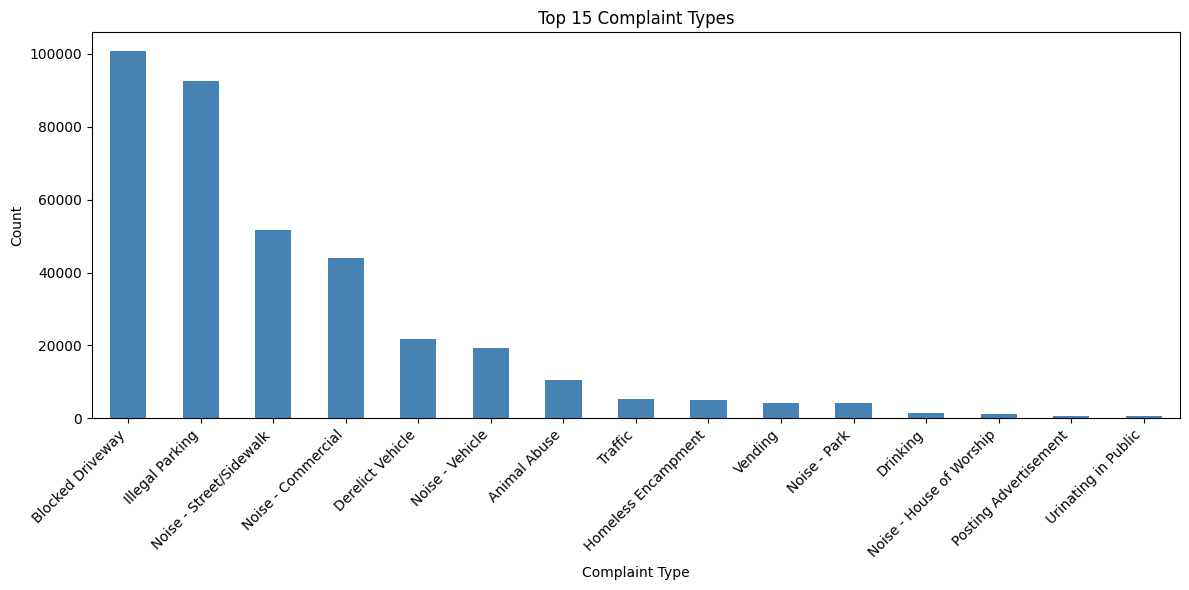

In [47]:
#Top Complaint Types:

plt.figure(figsize=(12,6))
df['Complaint Type'].value_counts().head(15).plot(kind='bar', color='steelblue')
plt.title('Top 15 Complaint Types')
plt.xlabel('Complaint Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

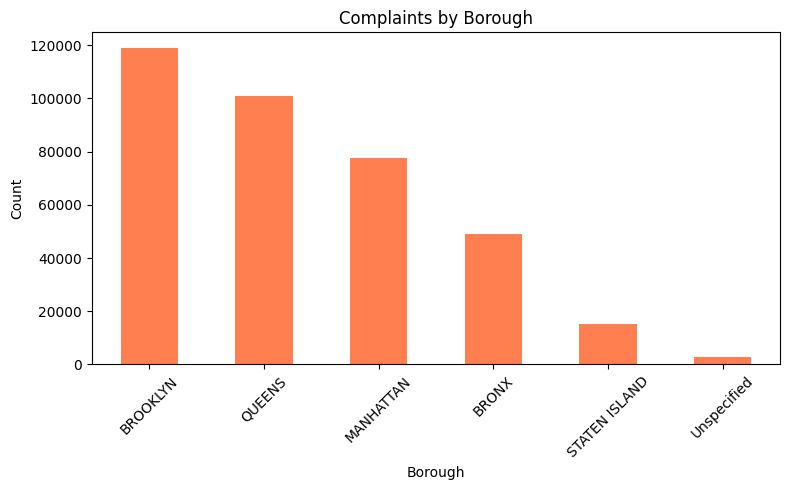

In [48]:
#Complaints by Borough:
plt.figure(figsize=(8,5))
df['Borough'].value_counts().plot(kind='bar', color='coral')
plt.title('Complaints by Borough')
plt.xlabel('Borough')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [49]:
df['Created Date'] = pd.to_datetime(df['Created Date'], format='mixed')
df['Year'] = df['Created Date'].dt.year
df['Month'] = df['Created Date'].dt.month
print("Done!", df['Month'].value_counts().sort_index())

Done! Month
1     20150
2     20719
3     25462
4     27305
5     36437
6     35315
7     34888
8     34956
9     35427
10    32605
11    30773
12    30521
Name: count, dtype: int64


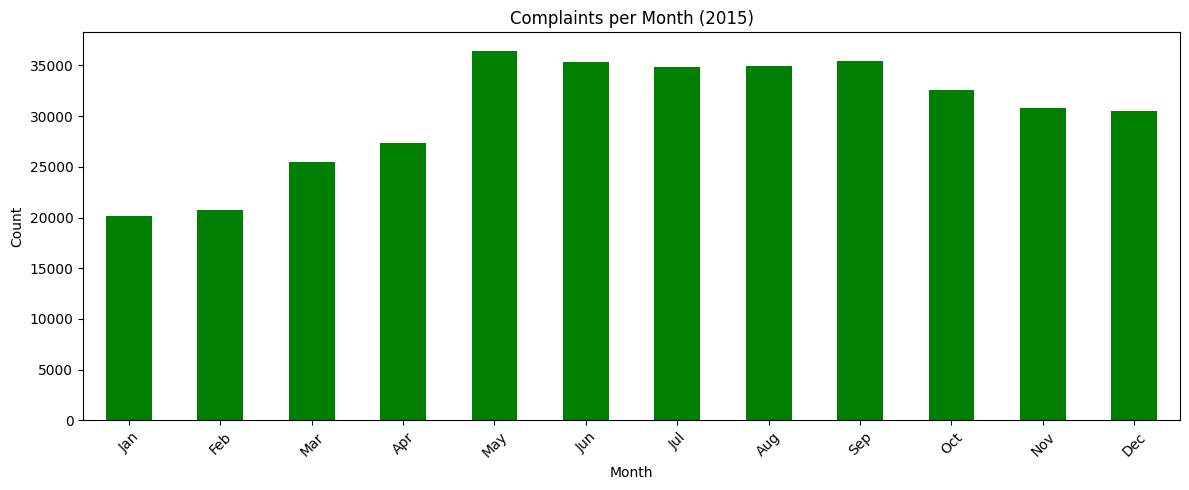

In [50]:
plt.figure(figsize=(12,5))
df['Month'].value_counts().sort_index().plot(kind='bar', color='green')
plt.title('Complaints per Month (2015)')
plt.xlabel('Month')
plt.ylabel('Count')
plt.xticks(ticks=range(12), labels=['Jan','Feb','Mar','Apr','May','Jun',
                                     'Jul','Aug','Sep','Oct','Nov','Dec'], rotation=45)
plt.tight_layout()
plt.show()

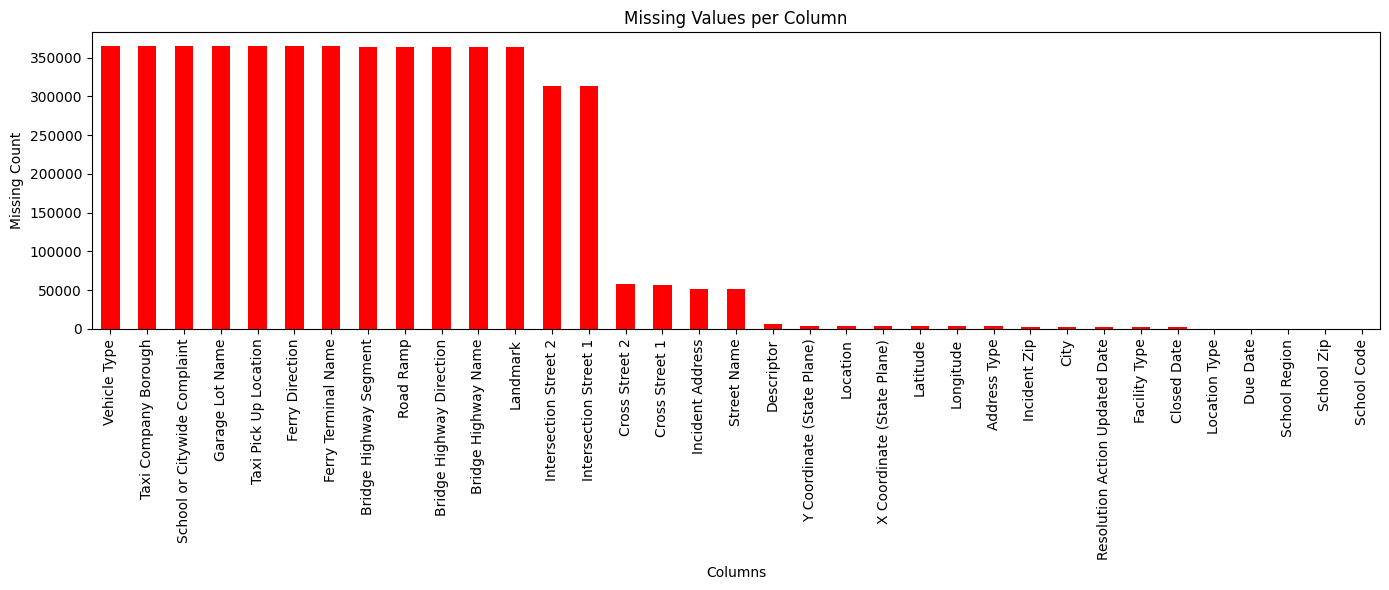

In [51]:
#Missing Values:
plt.figure(figsize=(14,6))
missing = df.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing.plot(kind='bar', color='red')
plt.title('Missing Values per Column')
plt.xlabel('Columns')
plt.ylabel('Missing Count')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

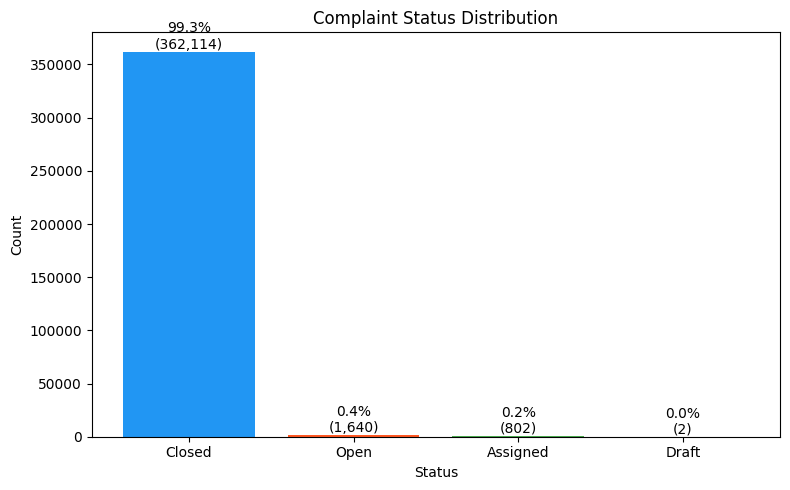

In [52]:
#Status Distribution:
plt.figure(figsize=(8,5))
status_counts = df['Status'].value_counts()
bars = plt.bar(status_counts.index, status_counts.values, 
               color=['#2196F3','#FF5722','#4CAF50','#FFC107'])

# Add count and percentage on top of each bar
total = len(df)
for bar, count in zip(bars, status_counts.values):
    pct = f'{100*count/total:.1f}%\n({count:,})'
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             pct, ha='center', va='bottom', fontsize=10)

plt.title('Complaint Status Distribution')
plt.xlabel('Status')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [53]:
# Duplicates check

print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


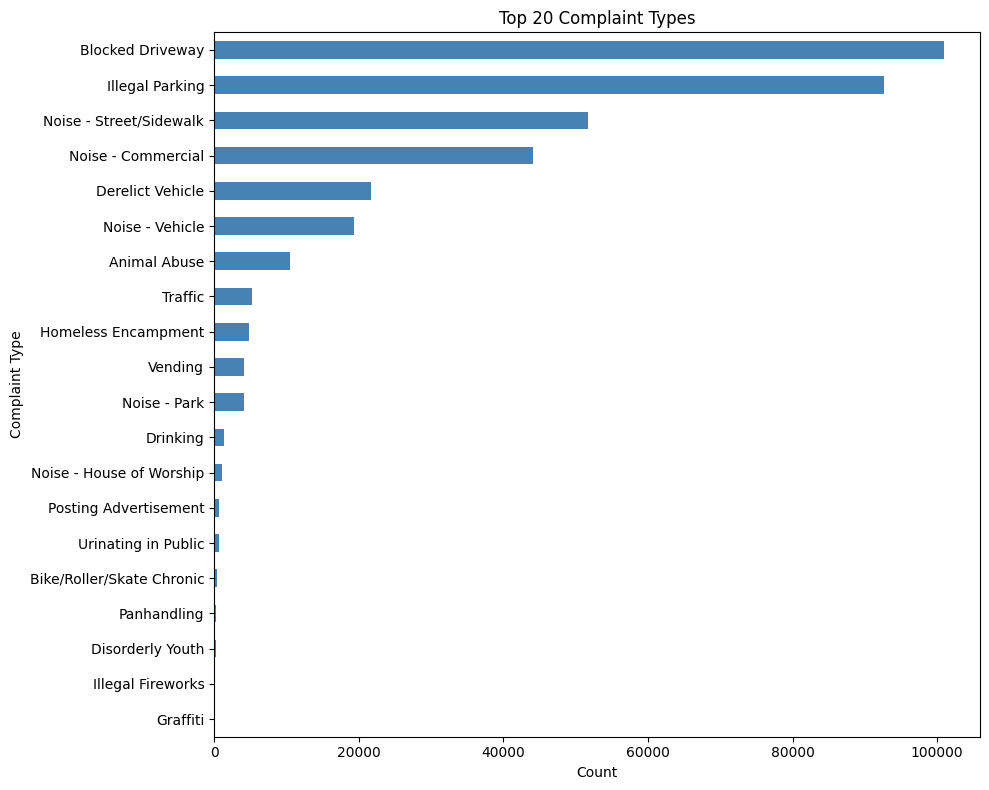

In [54]:
#Top 20 Horizontal Bar:
plt.figure(figsize=(10,8))
df['Complaint Type'].value_counts().head(20).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 20 Complaint Types')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig('notebooks/top20_complaints.png', dpi=150)
plt.show()

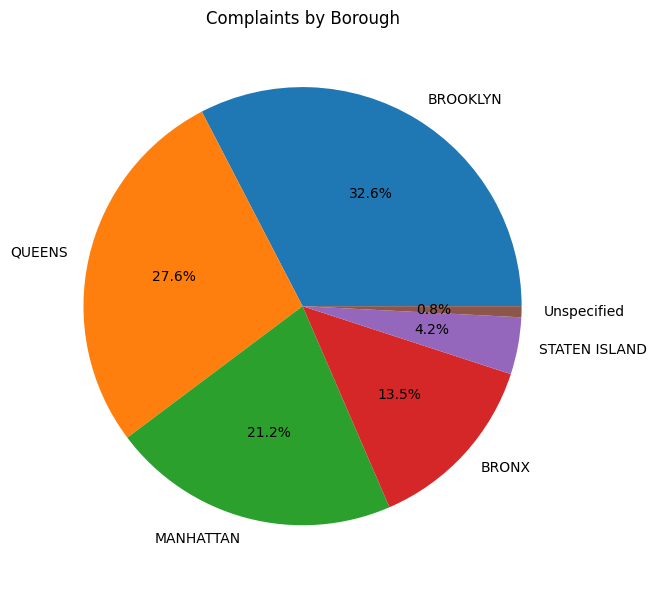

In [55]:
#Borough Pie Chart:
plt.figure(figsize=(8,6))
borough_counts = df['Borough'].value_counts()
plt.pie(borough_counts, labels=borough_counts.index, autopct='%1.1f%%')
plt.title('Complaints by Borough')
plt.tight_layout()
plt.savefig('notebooks/borough_pie.png', dpi=150)
plt.show()